# EDA

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [25]:
df = pd.read_csv("../data/gold/Netflix_Featured_Scaled_Data.csv")
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,...,content_age_missing_scaled,content_age_when_added_scaled,date_added_missing_scaled,duration_num_scaled,num_countries_scaled,num_genres_scaled,cast_count_scaled,title_word_count_scaled,description_word_count_scaled,is_movie_scaled
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,2021-09-25,2020,PG-13,90 min,...,0.0,-0.415543,-0.106079,0.397030,-0.346191,-1.522448,-1.348169,0.477527,1.099136,0.660659
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,...,0.0,-0.529744,-0.106079,-1.334584,-0.346191,1.027609,2.458469,-0.059516,1.099136,-1.513640
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,2021-09-24,2021,TV-MA,1 Season,...,0.0,-0.529744,-0.106079,-1.354262,-0.346191,1.027609,0.343670,-1.133602,1.099136,-1.513640
3,s4,TV Show,Jailbirds New Orleans,Unknown,Unknown,Unknown,2021-09-24,2021,TV-MA,1 Season,...,0.0,-0.529744,-0.106079,-1.354262,-0.346191,-0.247419,-1.348169,-0.059516,0.041511,-1.513640
4,s5,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,...,0.0,-0.529744,-0.106079,-1.334584,-0.346191,1.027609,0.132190,-0.596559,0.041511,-1.513640


In [26]:
df.tail()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,...,content_age_missing_scaled,content_age_when_added_scaled,date_added_missing_scaled,duration_num_scaled,num_countries_scaled,num_genres_scaled,cast_count_scaled,title_word_count_scaled,description_word_count_scaled,is_movie_scaled
8802,s8803,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,2019-11-20,2007,R,158 min,...,0.0,0.840668,-0.106079,1.735095,-0.346191,1.027609,0.555150,-1.133602,0.394053,0.660659
8803,s8804,TV Show,Zombie Dumb,Unknown,Unknown,Unknown,2019-07-01,2018,TV-Y7,2 Seasons,...,0.0,-0.415543,-0.106079,-1.334584,-0.346191,1.027609,-1.348169,-0.596559,-1.368657,-1.513640
8804,s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,2019-11-01,2009,R,88 min,...,0.0,0.612266,-0.106079,0.357675,-0.346191,-0.247419,-0.079290,-1.133602,0.394053,0.660659
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,2020-01-11,2006,PG,88 min,...,0.0,1.069070,-0.106079,0.357675,-0.346191,-0.247419,0.343670,-1.133602,0.746595,0.660659
8806,s8807,Movie,Zubaan,Mozez Singh,"Vicky Kaushal, Sarah-Jane Dias, Raaghav Chanan...",India,2019-03-02,2015,TV-14,111 min,...,0.0,-0.072940,-0.106079,0.810256,-0.346191,1.027609,0.132190,-1.133602,0.394053,0.660659


In [27]:
print("Size of the dataset:", df.shape)
print("Columns in the dataset:", df.columns)

Size of the dataset: (8807, 46)
Columns in the dataset: Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description',
       'date_added_cleaned', 'date_added_missing', 'year_added', 'month_added',
       'day_added', 'content_age_when_added', 'is_movie', 'primary_country',
       'primary_genre', 'duration_num', 'num_countries', 'num_genres',
       'cast_count', 'title_word_count', 'description_word_count',
       'content_age', 'content_age_missing', 'release_decade',
       'release_year_scaled', 'release_decade_scaled', 'year_added_scaled',
       'month_added_scaled', 'day_added_scaled', 'content_age_scaled',
       'content_age_missing_scaled', 'content_age_when_added_scaled',
       'date_added_missing_scaled', 'duration_num_scaled',
       'num_countries_scaled', 'num_genres_scaled', 'cast_count_scaled',
       'title_word_count_scaled', 'description_word_count_scaled',
       'is_movie_

In [28]:
import os

EDA_IMAGE_DIR = os.path.join("..", "eda_images")
os.makedirs(EDA_IMAGE_DIR, exist_ok=True)

def save_plot(filename: str) -> None:
    plt.tight_layout()
    plt.savefig(os.path.join(EDA_IMAGE_DIR, filename), dpi=300, bbox_inches="tight")

### 1. Content Growth Over Time
This chart shows how many titles were added to Netflix each year.

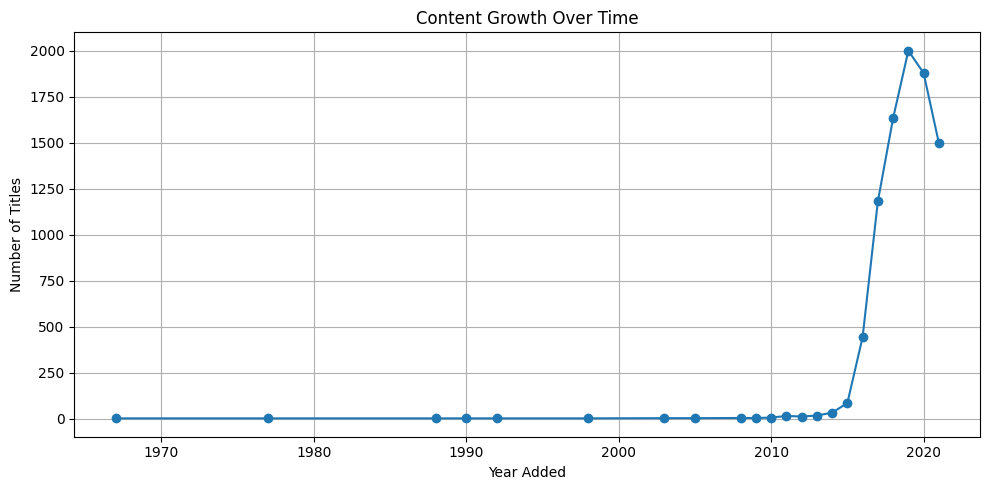

In [29]:
yearly_content = df["year_added"].dropna().astype(int).value_counts().sort_index()

plt.figure(figsize=(10, 5))
plt.plot(yearly_content.index, yearly_content.values, marker="o")
plt.title("Content Growth Over Time")
plt.xlabel("Year Added")
plt.ylabel("Number of Titles")
plt.grid()
save_plot("01_content_growth_over_time.png")
plt.show()

### 2. Content Age
How old the content was when it got added to Netflix.

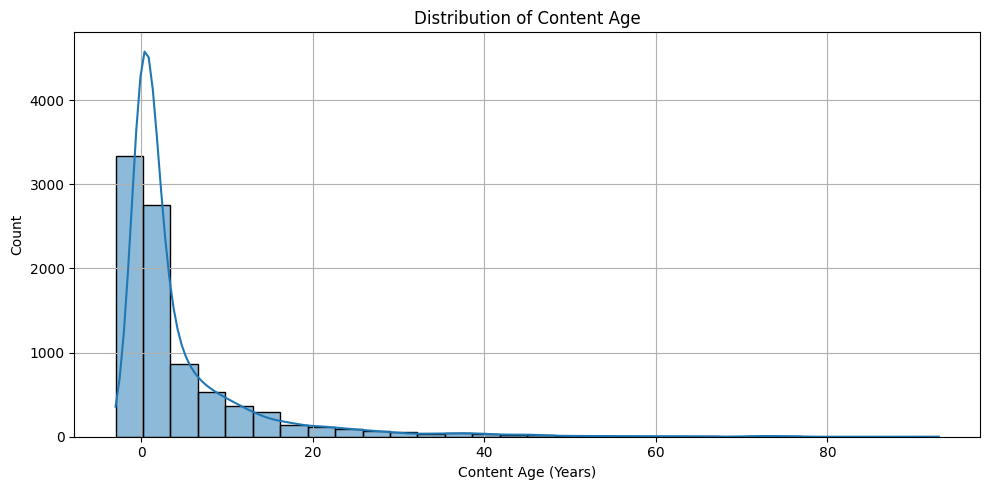

In [30]:
if "content_age" in df.columns:
    plt.figure(figsize=(10, 5))
    sns.histplot(df["content_age"], bins=30, kde=True)
    plt.title("Distribution of Content Age")
    plt.xlabel("Content Age (Years)")
    plt.ylabel("Count")
    plt.grid()
    save_plot("02_content_age.png")
    plt.show()
else:
    print("content_age column not found")

### 3. Movies vs TV Shows Split
Comparison of total Movies and TV Shows.

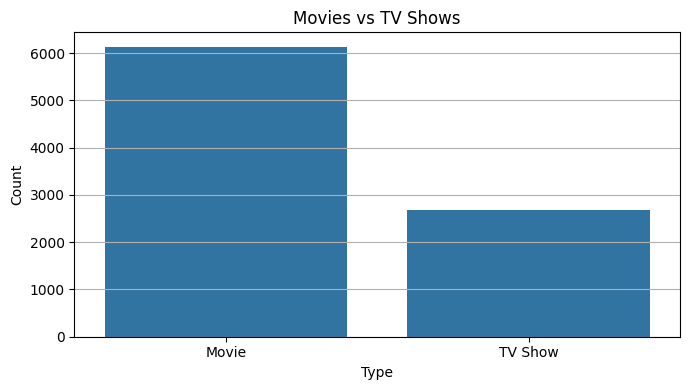

In [31]:
if "type" in df.columns:
    plt.figure(figsize=(7, 4))
    sns.countplot(data=df, x="type")
    plt.title("Movies vs TV Shows")
    plt.xlabel("Type")
    plt.ylabel("Count")
    plt.grid(axis="y")
    save_plot("03_movies_vs_tv_shows_split.png")
    plt.show()
else:
    print("type column not found")

### 4. Duration Analysis
Duration pattern comparison between Movies and TV Shows.

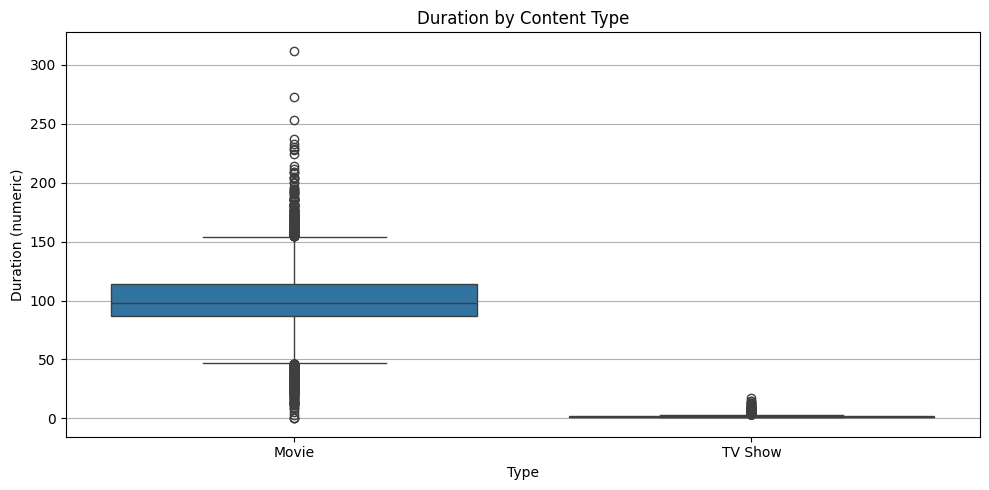

In [32]:
if {"type", "duration_num"}.issubset(df.columns):
    plt.figure(figsize=(10, 5))
    sns.boxplot(data=df, x="type", y="duration_num")
    plt.title("Duration by Content Type")
    plt.xlabel("Type")
    plt.ylabel("Duration (numeric)")
    plt.grid(axis="y")
    save_plot("04_duration_analysis.png")
    plt.show()
else:
    print("type or duration_num column not found")

### 5. Correlation Matrix
Correlation among important numeric features used in modeling.

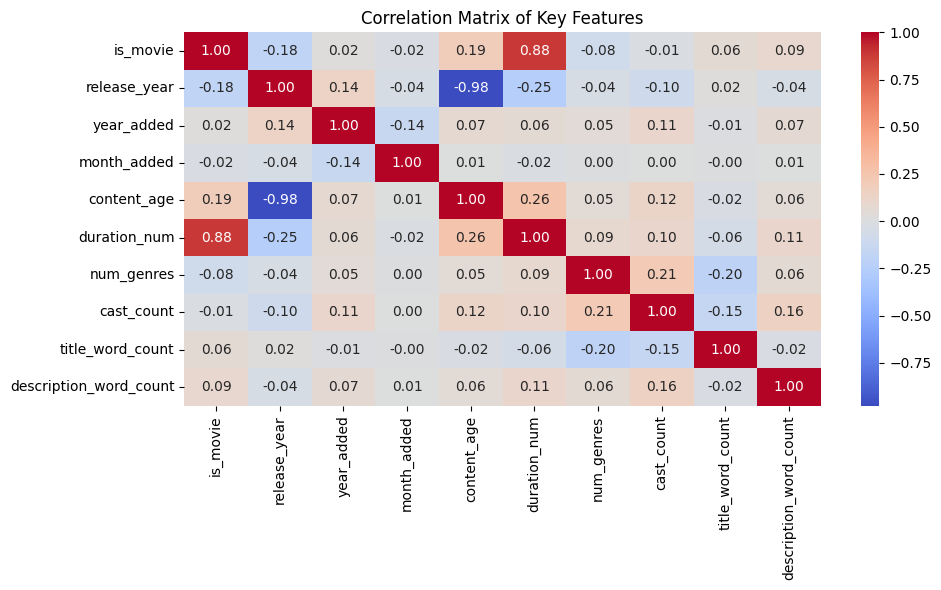

In [33]:
corr_cols = [
    "is_movie", "release_year", "year_added", "month_added",
    "content_age", "duration_num", "num_genres", "cast_count",
    "title_word_count", "description_word_count",
]
corr_cols = [c for c in corr_cols if c in df.columns]

if len(corr_cols) >= 2:
    plt.figure(figsize=(10, 6))
    sns.heatmap(df[corr_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f")
    plt.title("Correlation Matrix of Key Features")
    save_plot("05_correlation_matrix.png")
    plt.show()
else:
    print("Not enough columns for correlation matrix")

### 6. Missing Data Impact
Check missing values and their percentage impact on the dataset.

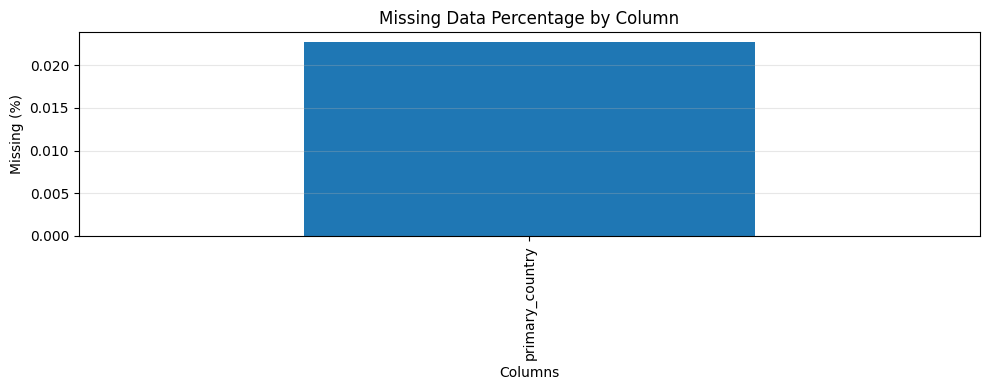

In [34]:
missing_pct = (df.isnull().mean() * 100).sort_values(ascending=False)
missing_pct = missing_pct[missing_pct > 0]

if not missing_pct.empty:
    plt.figure(figsize=(10, 4))
    missing_pct.plot(kind="bar")
    plt.title("Missing Data Percentage by Column")
    plt.ylabel("Missing (%)")
    plt.xlabel("Columns")
    plt.grid(axis="y", alpha=0.3)
    save_plot("06_missing_data_impact.png")
    plt.show()
else:
    print("No missing values found")

### 7. Monthly Trend
Monthly pattern of content additions across the year.

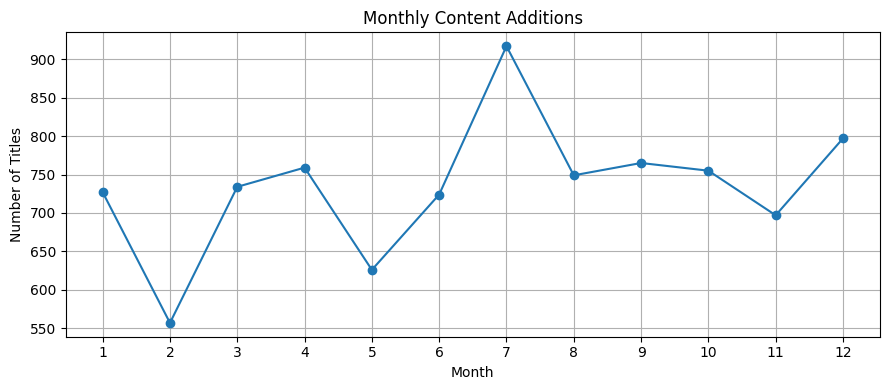

In [35]:
if "month_added" in df.columns:
    monthly = df["month_added"].dropna().astype(int).value_counts().sort_index()
    plt.figure(figsize=(9, 4))
    plt.plot(monthly.index, monthly.values, marker="o")
    plt.title("Monthly Content Additions")
    plt.xlabel("Month")
    plt.ylabel("Number of Titles")
    plt.xticks(range(1, 13))
    plt.grid()
    save_plot("07_monthly_trend.png")
    plt.show()
else:
    print("month_added column not found")

### 8. Genre Complexity
How many genre tags are assigned per title.

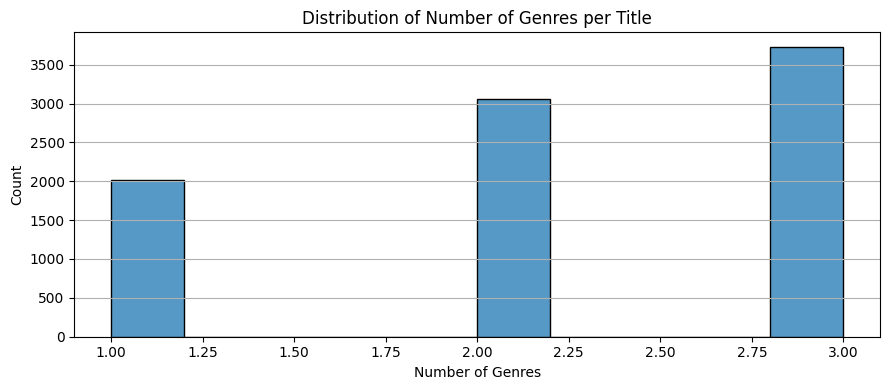

In [36]:
if "num_genres" in df.columns:
    plt.figure(figsize=(9, 4))
    sns.histplot(df["num_genres"], bins=10, kde=False)
    plt.title("Distribution of Number of Genres per Title")
    plt.xlabel("Number of Genres")
    plt.ylabel("Count")
    plt.grid(axis="y")
    save_plot("08_genre_complexity.png")
    plt.show()
else:
    print("num_genres column not found")

### 9. Cast Size (Production Scale)
Distribution of cast size as a simple proxy for production scale.

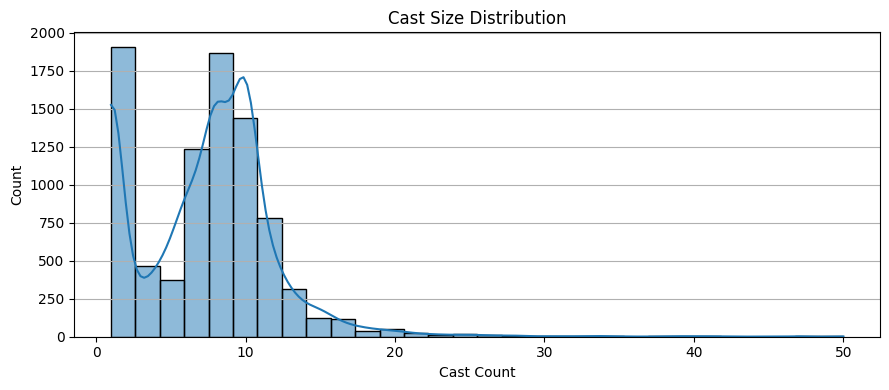

In [37]:
if "cast_count" in df.columns:
    plt.figure(figsize=(9, 4))
    sns.histplot(df["cast_count"], bins=30, kde=True)
    plt.title("Cast Size Distribution")
    plt.xlabel("Cast Count")
    plt.ylabel("Count")
    plt.grid(axis="y")
    save_plot("09_cast_size.png")
    plt.show()
else:
    print("cast_count column not found")

### 10. Outliers in Duration
Detect extreme duration values using a simple IQR-based method.

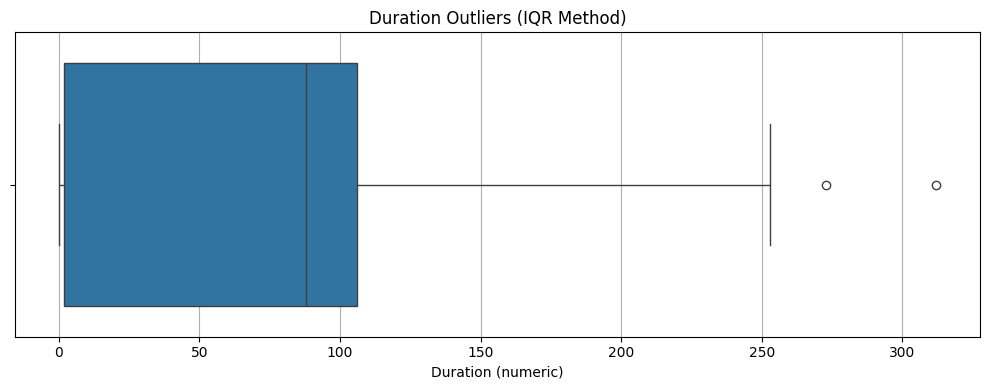

Outlier count: 2
Outlier percentage: 0.02 %


In [38]:
if "duration_num" in df.columns:
    q1 = df["duration_num"].quantile(0.25)
    q3 = df["duration_num"].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    outliers = df[(df["duration_num"] < lower) | (df["duration_num"] > upper)]

    plt.figure(figsize=(10, 4))
    sns.boxplot(x=df["duration_num"])
    plt.title("Duration Outliers (IQR Method)")
    plt.xlabel("Duration (numeric)")
    plt.grid(axis="x")
    save_plot("10_duration_outliers.png")
    plt.show()

    print("Outlier count:", len(outliers))
    print("Outlier percentage:", round(len(outliers) * 100 / len(df), 2), "%")
else:
    print("duration_num column not found")

### 11. Pie Charts content type and top genres

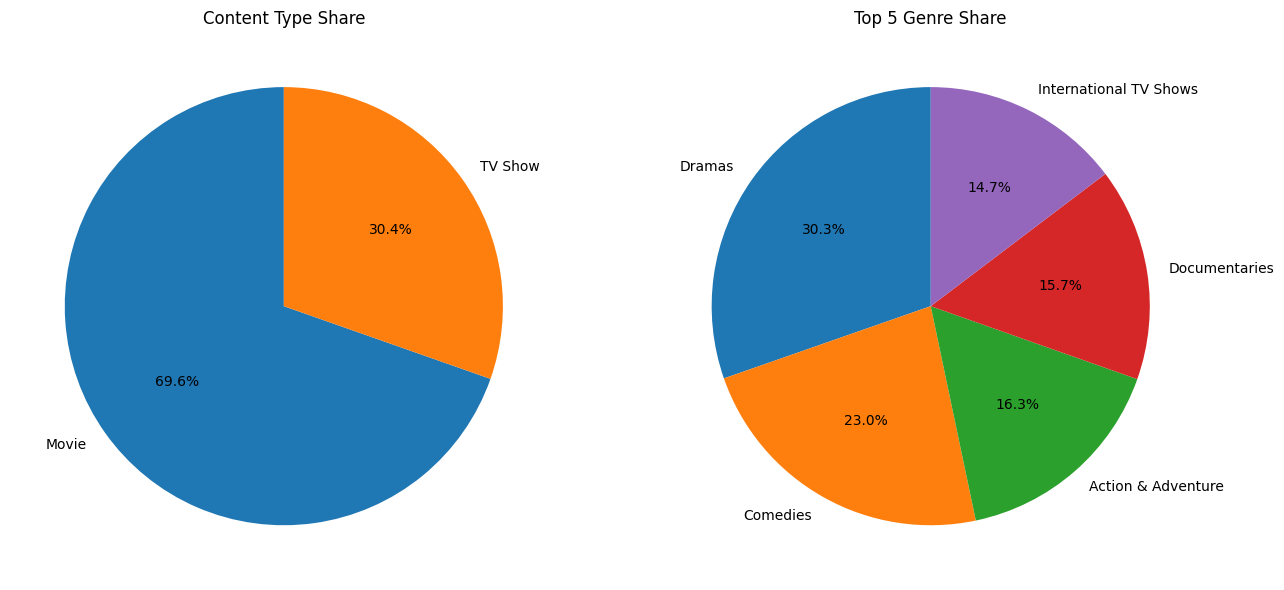

In [39]:
# One figure with 2 pie charts
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Pie 1: Movies vs TV Shows share
if "type" in df.columns:
    type_counts = df["type"].value_counts()
    axes[0].pie(
        type_counts.values,
        labels=type_counts.index,
        autopct="%1.1f%%",
        startangle=90
    )
    axes[0].set_title("Content Type Share")
else:
    axes[0].text(0.5, 0.5, "type column not found", ha="center", va="center")
    axes[0].axis("off")

# Pie 2: Top 5 primary genres share
if "primary_genre" in df.columns:
    genre_counts = df["primary_genre"].value_counts().head(5)
    axes[1].pie(
        genre_counts.values,
        labels=genre_counts.index,
        autopct="%1.1f%%",
        startangle=90
    )
    axes[1].set_title("Top 5 Genre Share")
else:
    axes[1].text(0.5, 0.5, "primary_genre column not found", ha="center", va="center")
    axes[1].axis("off")

fig.tight_layout()
fig.savefig(os.path.join(EDA_IMAGE_DIR, "11_pie_charts_combined.png"), dpi=300, bbox_inches="tight")
plt.show()